In [ ]:
# Imports

import os 
import shutil
import ast 
import pickle 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gensim Stuff
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# Scikit Learn - For NMF Topic Modelling 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics import silhouette_score 
from sklearn.metrics.pairwise import cosine_similarity

# BERTopic Stuff 
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

print("All imports done") 

All imports done


### Preprocessing

- I have the output already saved as songs_preprocessed.parquet, but I've put the chunk with the preprocessing below.
- It's the same as what Ishita did. 

Other than that, can proceed to loading of data in the following cell after.

In [ ]:
# Pre Processing 

# 1. Dropping columns not needed
cols_to_drop = ['key', 'mode', 'loudness', 'liveness',
                'acousticness', 'instrumentalness', 'tempo',
                'duration_ms', 'album_name', 'artist_ids']

songs_df = songs_df.drop(columns=cols_to_drop)
print("Remaining Columns:", songs_df.columns.tolist())

# 2. Drop songs with timestamps in lyrics 
has_timestamp = songs_df['lyrics'].str.contains(
    r'\[\d{2}:\d{2}\.\d{2,3}\]', regex=True, na=False
)
print("Songs with timestamps:", has_timestamp.sum())

# 3. Drop songs with timestamps in the lyrics
songs_df = songs_df[~has_timestamp]
print("Songs remaining:", len(songs_df))

# 4. Drop Songs with Repeated Lines - Reduce noise 
songs_df['lyrics_clean'] = songs_df['lyrics']

def remove_repeated_lines(text):
    lines = text.split('\n')
    cleaned = []
    previous_line = None
    
    for line in lines:
        line = line.strip()
        if line != previous_line and line != '':
            cleaned.append(line)
            previous_line = line
    
    return '\n'.join(cleaned)

songs_df['lyrics_clean'] = songs_df['lyrics_clean'].apply(remove_repeated_lines)

# 4. Tokenize cleaned lyrics and count words
songs_df['tokens'] = songs_df['lyrics_clean'].apply(word_tokenize)

songs_df['word_count'] = songs_df['tokens'].apply(len)

# 5. Drop songs with very short lyircs (Keep songs with more than 20 words) 
print("Before dropping songs with less than 20 words:", len(songs_df))
songs_df = songs_df[songs_df['word_count'] >= 20]
print("")
print("After dropping songs with less than 20 words:", len(songs_df))

#6. Pre Process Lyrics 
stop_words = set(stopwords.words('english'))
lyrics_stopwords = {
    'yeah', 'oh', 'ooh', 'ah', 'na', 'la', 'ha',
    'gonna', 'wanna', 'gotta', 'chorus', 'verse',
    'hook', 'bridge', 'repeat', 'whoa', 'aye', 'ay'
}
stop_words.update(lyrics_stopwords)
lemmatizer = WordNetLemmatizer()

def process_lyrics(text):
    text = text.replace('\n', ' ')
    
    tokens_lower = word_tokenize(text.lower())
    tokens_alpha = [t for t in tokens_lower if re.search('^[a-z]+$',t)]
    tokens_stop = [t for t in tokens_alpha if t not in stop_words]
    tokens_lem = [lemmatizer.lemmatize(t) for t in tokens_stop]
    return tokens_lem

# Re run on lyrics 
songs_df['tokens_lemma'] = songs_df['lyrics_clean'].apply(process_lyrics)

# Check the same song again
print(songs_df['tokens_lemma'].iloc[0][:15])

### Load Preprocessed Data below.

Saved it in a parquet cause 550k is alot and i'm using a baby laptop

In [2]:
songs_df = pd.read_parquet("./data/songs_preprocessed.parquet")

# "token_lemma" stores a list of cleaned words originally. will need to convert them back to actual python lists after saving it to parquet. 

def safe_parse(val):
    if isinstance(val, (list, np.ndarray)): 
        return list(val)
    
    try: 
        return ast.literal_eval(val) 
    
    except: 
        return val.strip("[]").replace("'", "").split(",")
    
songs_df['tokens_lemma'] = songs_df["tokens_lemma"].apply(safe_parse) 

# For NMF (TF-IDF Vectoriser) and BERTopic (CountVectorizer) - I create a tokens_joined, where ceaned tokens are joined back into string for count. 

songs_df['tokens_joined'] = songs_df['tokens_lemma'].apply(lambda x: " ".join(x))

print(f" Loaded dataset: {songs_df.shape[0]:,} songs, {songs_df.shape[1]} columns.")
songs_df[['name', 'genre', 'popularity', 'tokens_lemma','tokens_joined']].head(5)

 Loaded dataset: 548,698 songs, 19 columns.


,name,genre,popularity,tokens_lemma,tokens_joined
0,!,Rock,0,"[said, came, jamaica, owned, couple, acre, cou...",said came jamaica owned couple acre couple fak...
1,!!,Hip-Hop,29,"[fuck, bitch, running, said, never, thing, wor...",fuck bitch running said never thing word said ...
2,!!Noble Stabbings!!,Rock,0,"[like, stand, side, point, laugh, line, drawn,...",like stand side point laugh line drawn plain c...
3,!I'll Be Back!,Hip-Hop,43,"[shit, missed, rehab, psyche, gone, ai, room, ...",shit missed rehab psyche gone ai room rest dem...
4,!Lost!,Hip-Hop,0,"[would, like, give, time, would, like, tell, m...",would like give time would like tell much love...


### LDA Model Portion
- Items are saved in lda, with model, dict, corpus and results created.
- Separated into: 
1. Loading In Files/Creation of LDA 
2. Evaluation Using Coherence Score and Perplexity. 

- Coherence - measures how semantically similar the top words in each topic are. Higher is better. 
- Perplexity - measures how surprised the model is when it sees the data. How well model predicts the words in these songs.

In [10]:
# Load in Files 

LDA_MODEL_PATH = "./lda/lda_model_k10" #This is at K=10 only. I haven't run for K to 20. 
LDA_DICT_PATH = "./lda/lda_dictionary.dict"
LDA_CORPUS_PATH = "./lda/lda_corpus.mm" 
LDA_RESULTS_PATH = "./lda/songs_with_lda.csv" 

if os.path.exists(LDA_MODEL_PATH): 
    print("Loading existing model:") 

    lda_model = LdaModel.load(LDA_MODEL_PATH) 
    dictionary = corpora.Dictionary.load(LDA_DICT_PATH) 
    corpus = corpora.MmCorpus(LDA_CORPUS_PATH) 
    songs_df_lda = pd.read_csv(LDA_RESULTS_PATH) 

    print(f"LDA Loaded: {len(songs_df_lda):,} songs with topic assignments.")

else: 
    # Do the Model from scratch. Will need to test from K = 10 to K = 20 and choose the best. 

    # Build Dictionary
    dictionary = corpora.Dictionary(songs_df['tokens_lemma'])
    dictionary.filter_extremes(no_below = 10, no_above = 0.5) # Filter out rare words and very common words (50% of songs) - rare words noise, super common not helpful

    # Build Corpus
    corpus = [dictionary.doc2bow(tokens) for tokens in songs_df['tokens_lemma']]

    # Train LDA 
    # Want can be tuned - number of topics, passes (longer tho) 

    lda_model = LdaModel(
        corpus = corpus,
        id2word = dictionary, 
        num_topics = 10,
        random_state = 42,
        passes = 10,
        alpha = 'auto'
    )

    # Assign songs dominant topic. 

    def get_dominant_topic(bow): 
        topics = lda_model.get_document_topics(bow) 
        return max(topics, key=lambda x: x[1])[0] if topics else -1
    
    songs_df['lda_topic'] = [get_dominant_topic(bow) for bow in corpus] 

    # Save all 

    lda_model.save(LDA_MODEL_PATH) 
    dictionary.save(LDA_DICT_PATH) 
    corpora.MmCorpus.serialize(LDA_CORPUS_PATH, corpus) 
    songs_df.to_csv(LDA_RESULTS_PATH, index = False) 
    songs_df_lda = songs_df.copy() 

    print("LDA Trained and Saved.") 


Loading existing model:
LDA Loaded: 548,698 songs with topic assignments.


### Evaluation

In [12]:
coherence_model = CoherenceModel(
    model = lda_model,
    texts = songs_df['tokens_lemma'],
    dictionary = dictionary, 
    coherence = 'c_v'
)

coherence_score = coherence_model.get_coherence()
log_perplexity_score = lda_model.log_perplexity(corpus) 
perplexity_score = 2**(-log_perplexity_score)

print(f" LDA Coherence Score: {coherence_score:.4f}.")
print(f" LDA Coherence Score: {log_perplexity_score:.4f}.")
print(f" LDA Perplexity : {perplexity_score:.4f}.")

 LDA Coherence Score: 0.4745.
 LDA Coherence Score: -7.7123.
 LDA Perplexity : 209.7170.


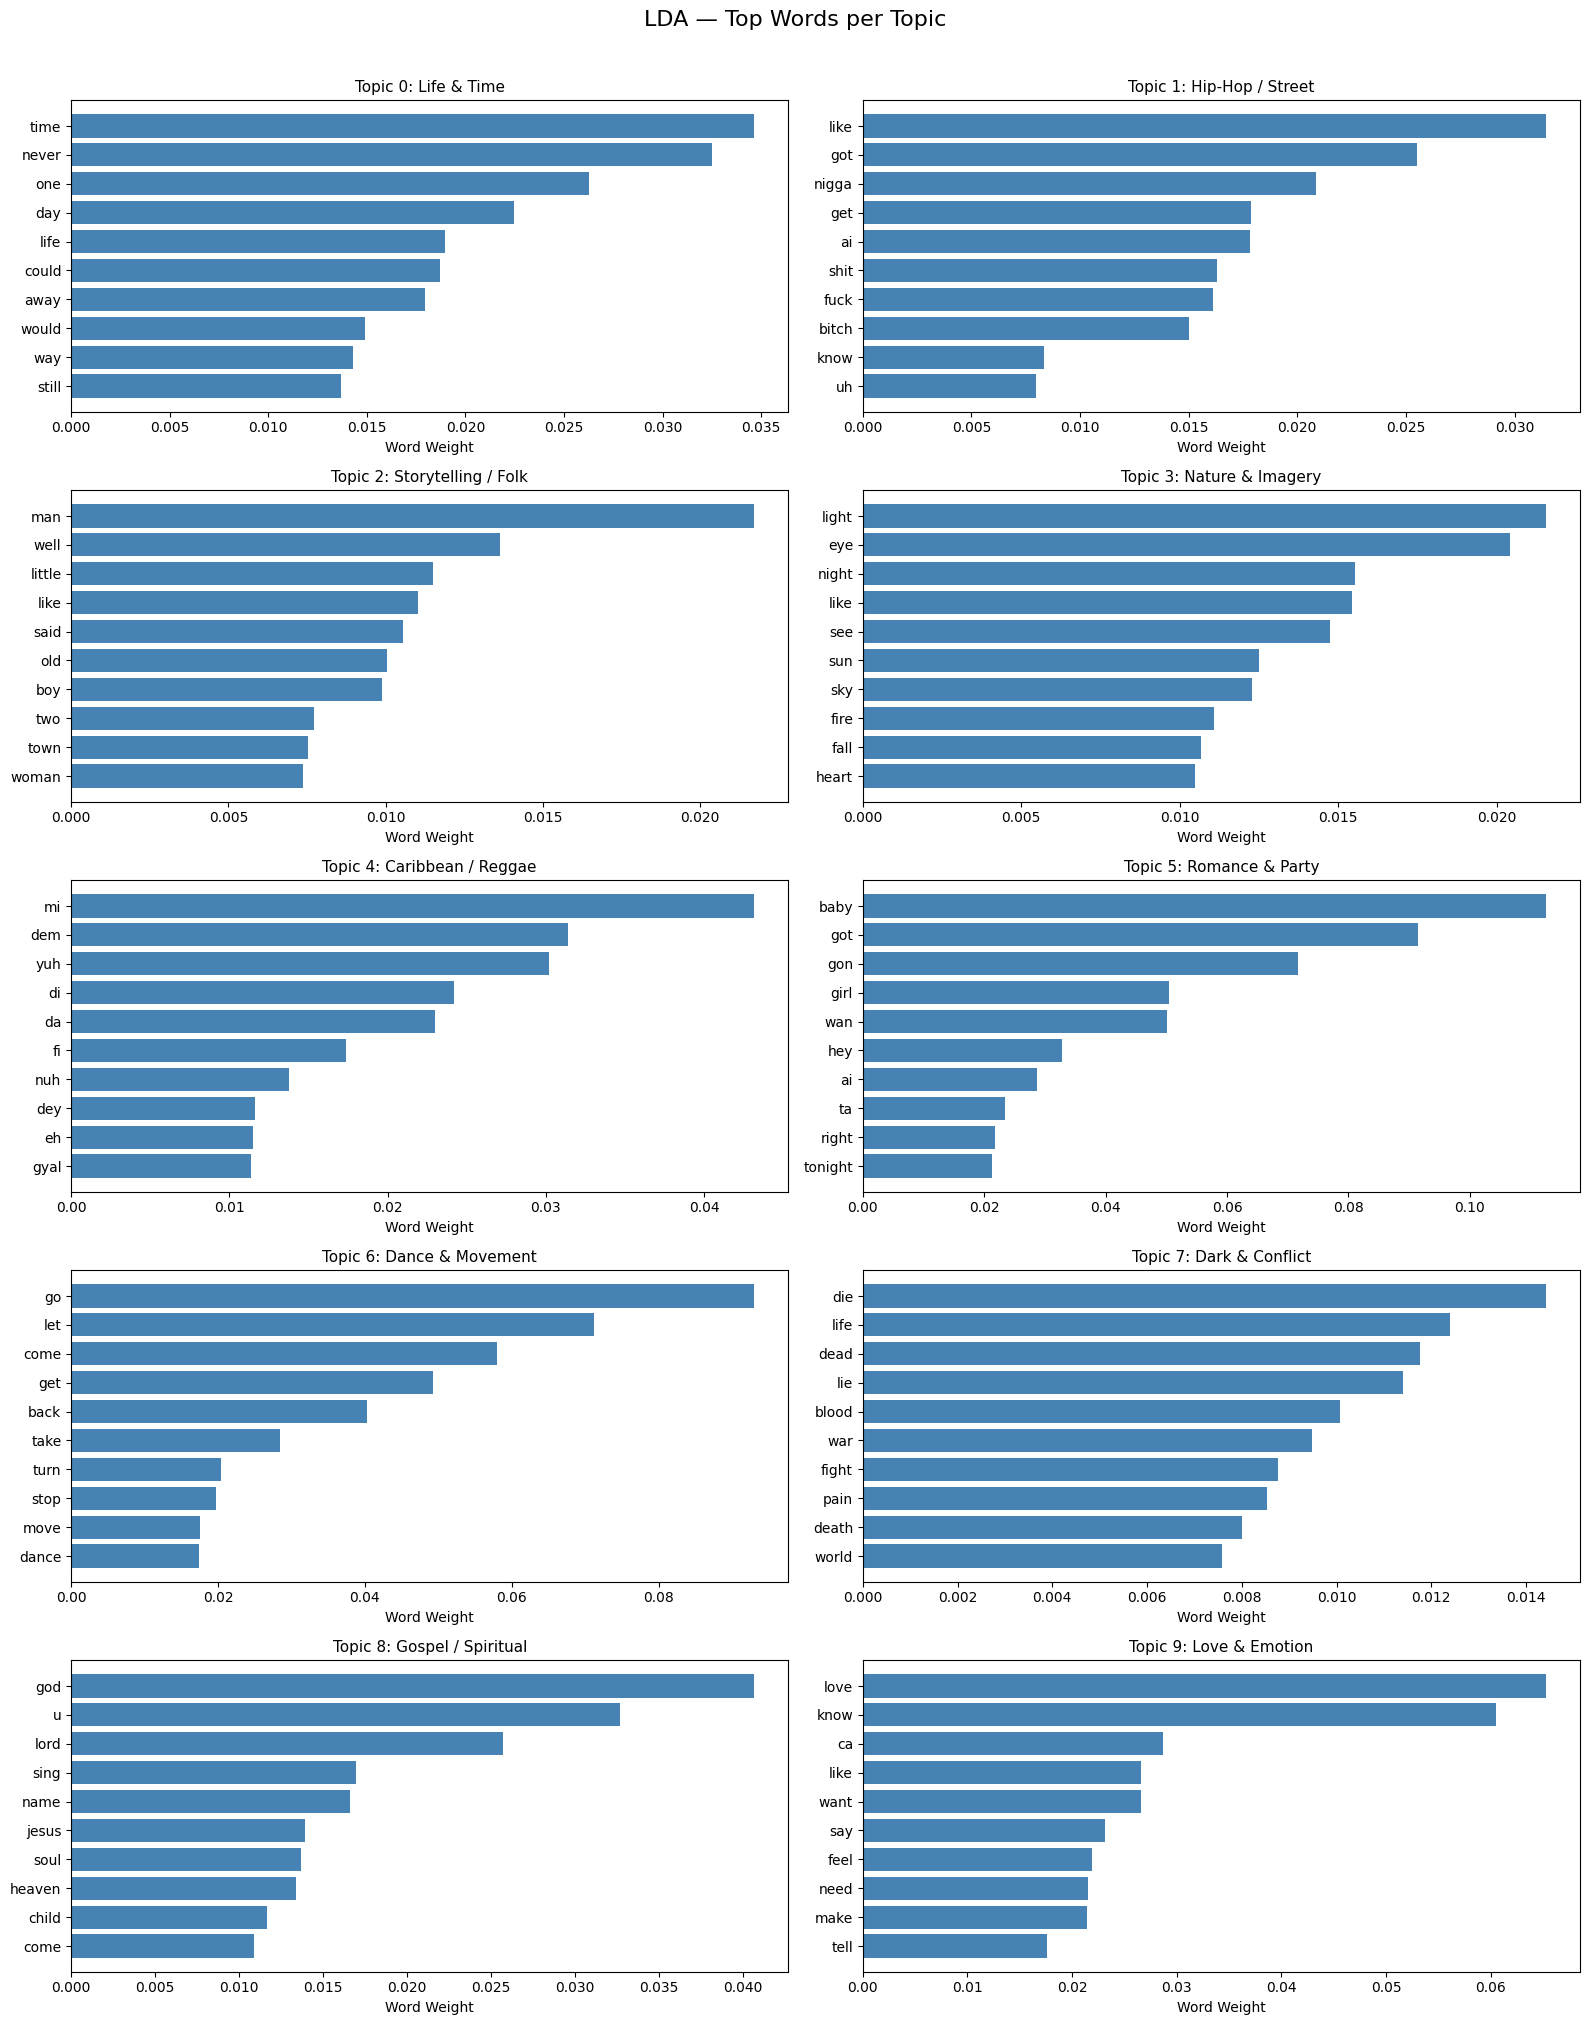

✅ Saved: lda_topic_words.png


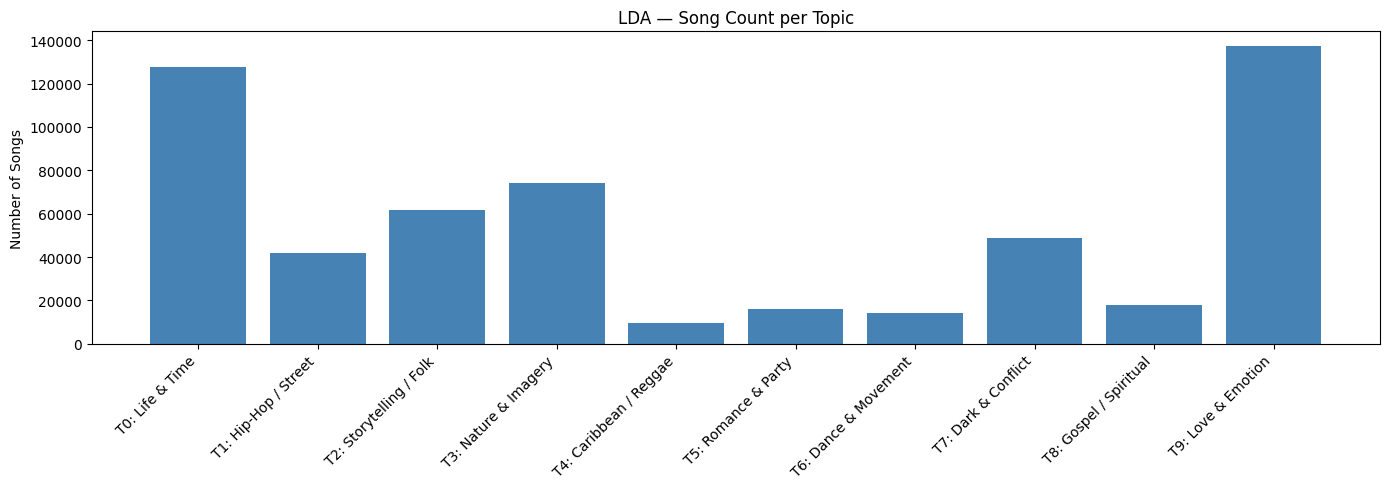

✅ Saved: lda_topic_distribution.png


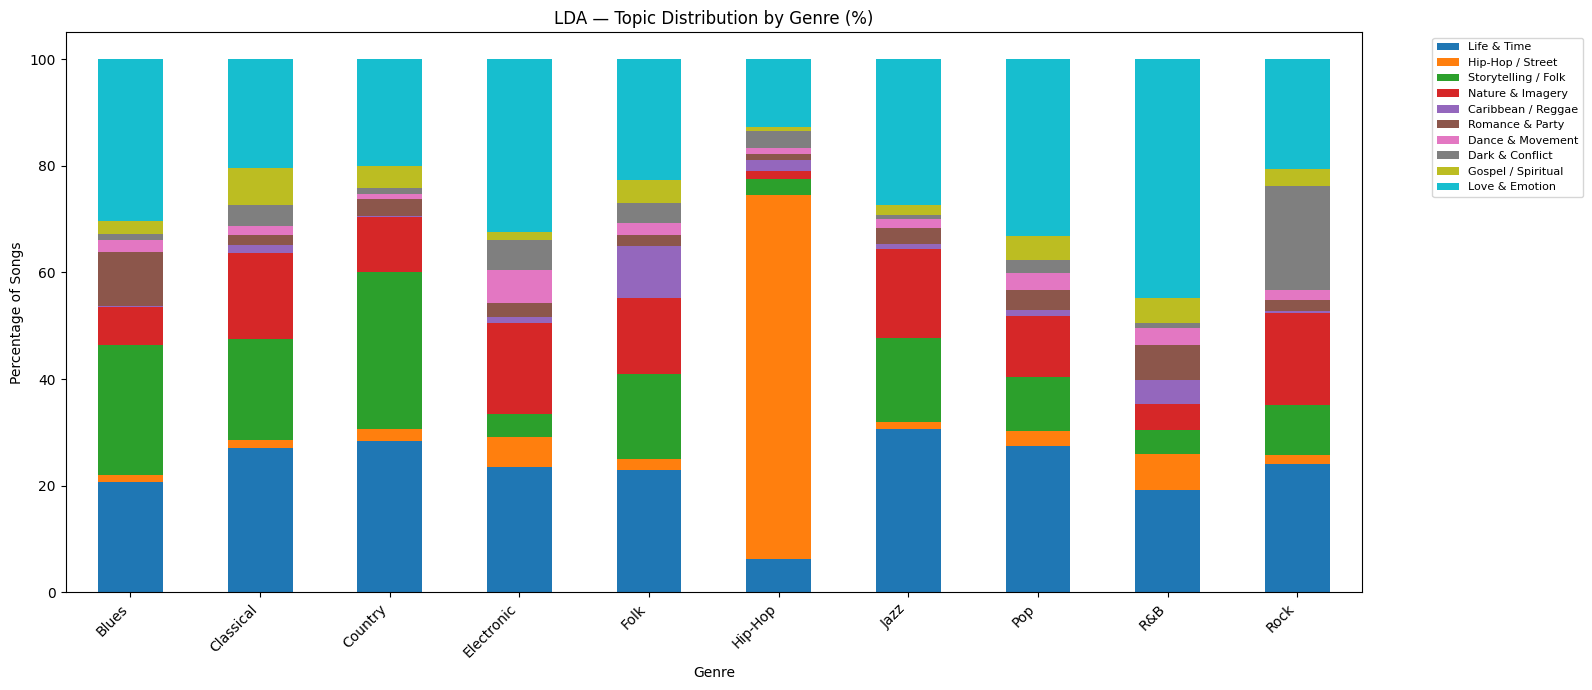

✅ Saved: lda_genre_distribution.png


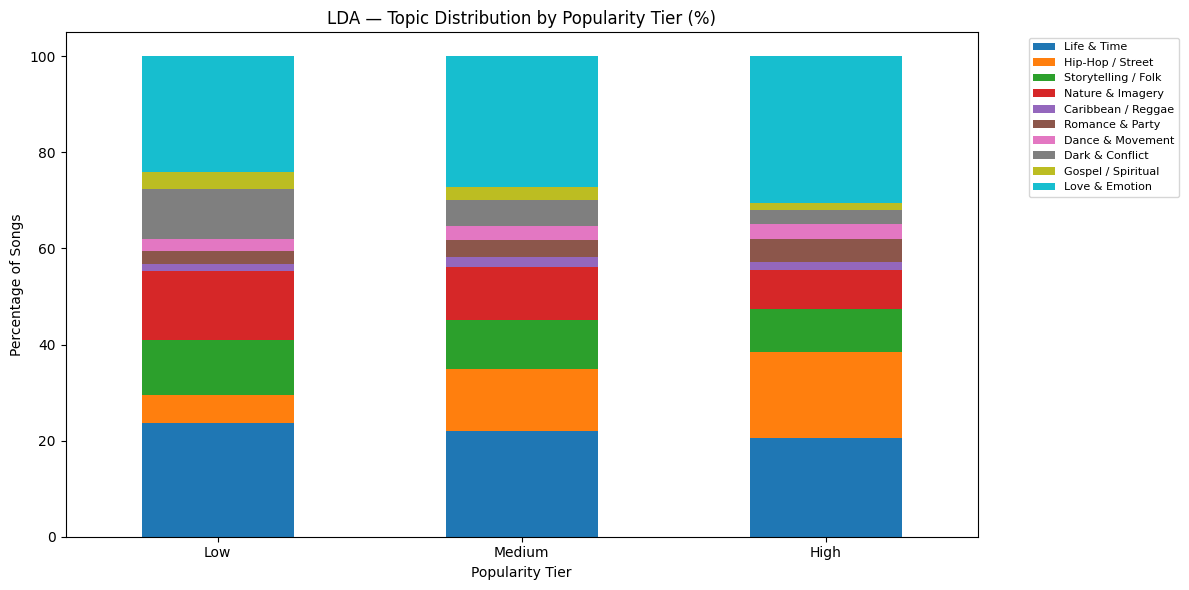

✅ Saved: lda_popularity_distribution.png


In [ ]:
# Can edit this topic label, i just came up with this first, feel free to change. 
topic_labels = {
    0: "Life & Time",
    1: "Hip-Hop / Street",
    2: "Storytelling / Folk",
    3: "Nature & Imagery",
    4: "Caribbean / Reggae",
    5: "Romance & Party",
    6: "Dance & Movement",
    7: "Dark & Conflict",
    8: "Gospel / Spiritual",
    9: "Love & Emotion"
}

# Chart 1: Word weight bar charts per topic
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for idx in range(10):
    topic_terms = lda_model.show_topic(idx, topn=10)
    words  = [w for w, _ in topic_terms]
    scores = [s for _, s in topic_terms]
    axes[idx].barh(words[::-1], scores[::-1], color='steelblue')
    axes[idx].set_title(f"Topic {idx}: {topic_labels[idx]}", fontsize=11)
    axes[idx].set_xlabel("Word Weight")

plt.suptitle("LDA — Top Words per Topic", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("lda_topic_words.png", bbox_inches='tight')
plt.show()
print("✅ Saved: lda_topic_words.png")

# Chart 2: HNo. of Songs Per Topic 
topic_counts = songs_df_lda['lda_topic'].value_counts().sort_index()
labels = [f"T{i}: {topic_labels[i]}" for i in topic_counts.index]

plt.figure(figsize=(14, 5))
plt.bar(labels, topic_counts.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Songs")
plt.title("LDA — Song Count per Topic")
plt.tight_layout()
plt.savefig("lda_topic_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: lda_topic_distribution.png")

# Chart 3: Topic distribution by genre 
# Think this is good for something like "Does Rock have more Dark & Conflict? Does Pop dominate Romance?"
# May be redundant though so can remove
lda_genre = songs_df_lda.groupby(['genre', 'lda_topic']).size().unstack(fill_value=0)
lda_genre.columns = [topic_labels.get(c, str(c)) for c in lda_genre.columns]
lda_genre_pct = lda_genre.div(lda_genre.sum(axis=1), axis=0) * 100  # convert to %

lda_genre_pct.plot(kind='bar', stacked=True, figsize=(16, 7), colormap='tab10')
plt.title("LDA — Topic Distribution by Genre (%)")
plt.ylabel("Percentage of Songs")
plt.xlabel("Genre")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("lda_genre_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: lda_genre_distribution.png")

# ── Chart 4: Topic distribution by popularity tier ──
# Popularity score 0-100 → split into Low (0-33), Medium (34-66), High (67-100)
songs_df_lda['popularity_tier'] = pd.cut(
    songs_df_lda['popularity'],
    bins=[0, 33, 66, 100],
    labels=['Low', 'Medium', 'High']
)

lda_pop = songs_df_lda.groupby(['popularity_tier', 'lda_topic']).size().unstack(fill_value=0)
lda_pop.columns = [topic_labels.get(c, str(c)) for c in lda_pop.columns]
lda_pop_pct = lda_pop.div(lda_pop.sum(axis=1), axis=0) * 100

lda_pop_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title("LDA — Topic Distribution by Popularity Tier (%)")
plt.ylabel("Percentage of Songs")
plt.xlabel("Popularity Tier")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("lda_popularity_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: lda_popularity_distribution.png")


In [ ]:
# LDA Tuning - Plotting Coherence Model vs num of topics in K from 10 to 20. See which value of K is the best. 
# I messed up and accidentally reloaded the output, but K = 10 is the best
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

coherence_values = []
model_list = []
topic_range = range(10, 21, 1)  # k = 5 to 20

for k in topic_range:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto'
    )
    cm = CoherenceModel(model=model, texts=songs_df['tokens_lemma'],
                        dictionary=dictionary, coherence='c_v')
    coherence_values.append(cm.get_coherence())
    model_list.append(model)
    print(f"k={k}  Coherence: {cm.get_coherence():.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(topic_range, coherence_values, marker='o')
plt.xlabel("Number of Topics (k)")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA — Coherence Score vs Number of Topics")
plt.xticks(list(topic_range))
plt.grid(True)
plt.tight_layout()
plt.savefig("lda_coherence_vs_k.png", bbox_inches='tight')
plt.show()

# Pick the best k
best_k = list(topic_range)[coherence_values.index(max(coherence_values))]
best_model = model_list[coherence_values.index(max(coherence_values))]
print(f"\nBest k = {best_k}  (Coherence: {max(coherence_values):.4f})")


k=10  Coherence: 0.4745
k=11  Coherence: 0.4560
k=12  Coherence: 0.4569
k=13  Coherence: 0.4518
k=14  Coherence: 0.4641
k=15  Coherence: 0.4691
k=16  Coherence: 0.4631


KeyboardInterrupt: 

### NMF Portion 
- Non-Negative Matrix Factorisation
- Decomposes a large matrix of songs x words into 
    - songs x topics 
    - topics x words 

- Uses TF-IDF weighted word counts rather than raw counts in LDA. 

Training NMF — running k=5 to k=20 to find best number of topics...
✅ TF-IDF fitted: 548,698 songs × 5,000 words
  k= 5  Diversity: 0.840  Recon Error: 718.5
  k= 6  Diversity: 0.833  Recon Error: 717.1
  k= 7  Diversity: 0.757  Recon Error: 715.9
  k= 8  Diversity: 0.688  Recon Error: 714.7
  k= 9  Diversity: 0.689  Recon Error: 713.5
  k=10  Diversity: 0.670  Recon Error: 712.4
  k=11  Diversity: 0.627  Recon Error: 711.1
  k=12  Diversity: 0.633  Recon Error: 710.2
  k=13  Diversity: 0.662  Recon Error: 709.1
  k=14  Diversity: 0.671  Recon Error: 708.0
  k=15  Diversity: 0.660  Recon Error: 707.1
  k=16  Diversity: 0.631  Recon Error: 706.1
  k=17  Diversity: 0.641  Recon Error: 705.1
  k=18  Diversity: 0.628  Recon Error: 704.1
  k=19  Diversity: 0.611  Recon Error: 702.8
  k=20  Diversity: 0.615  Recon Error: 701.8


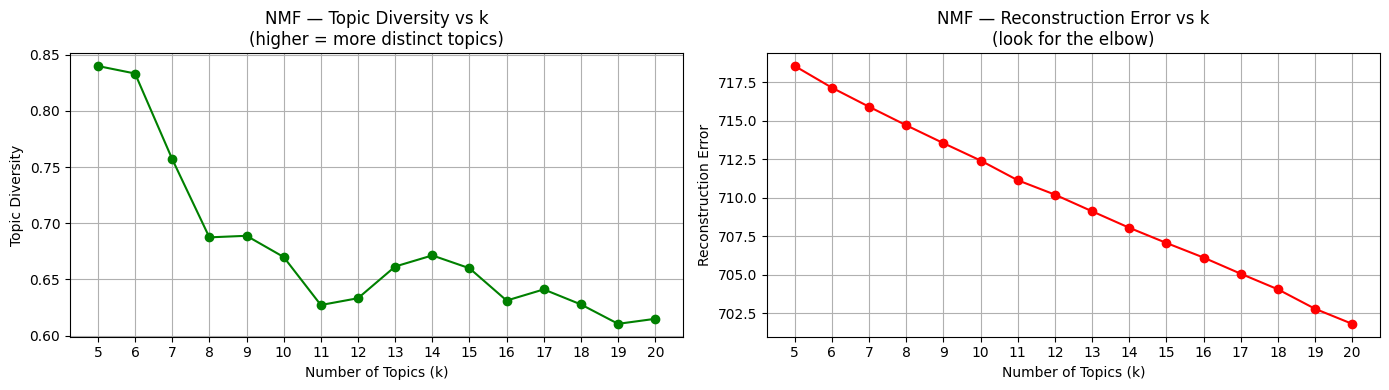

✅ Saved: ./nmf/nmf_tuning.png

── Best k by diversity = 5 ──
(Check the charts above — if diversity plateaus early, pick that earlier k)
Update NUM_TOPICS below and rerun if needed.

Training final NMF model with k=5...

── Top 10 Words per NMF Topic (k=5) ──
  Topic  0: ['know', 'go', 'let', 'want', 'wan', 'say', 'ca', 'feel', 'need', 'tell']
  Topic  1: ['love', 'heart', 'need', 'give', 'true', 'like', 'always', 'never', 'forever', 'say']
  Topic  2: ['got', 'get', 'like', 'nigga', 'ai', 'bitch', 'shit', 'gon', 'ta', 'fuck']
  Topic  3: ['baby', 'girl', 'come', 'hey', 'gon', 'night', 'good', 'little', 'well', 'got']
  Topic  4: ['time', 'one', 'life', 'day', 'away', 'see', 'never', 'come', 'night', 'eye']

Final NMF Topic Diversity: 0.840

✅ NMF model saved! (k=5)
   → ./nmf/songs_with_nmf.csv
   → ./nmf/nmf_model.pkl
   → ./nmf/tfidf_vectorizer.pkl
   → ./nmf/tuning_results.csv
   → ./nmf/nmf_tuning.png


In [ ]:
os.makedirs("./nmf", exist_ok=True)  # create folder if it doesn't exist

NMF_RESULTS_PATH = "./nmf/songs_with_nmf.csv"
NMF_MODEL_PATH   = "./nmf/nmf_model.pkl"
TFIDF_PATH       = "./nmf/tfidf_vectorizer.pkl"
TUNING_PATH      = "./nmf/tuning_results.csv"

# Load Data in like before, if not build model from scratch 
if os.path.exists(NMF_RESULTS_PATH):
    print("Loading existing NMF model...")

    songs_df_nmf = pd.read_csv(NMF_RESULTS_PATH)

    with open(NMF_MODEL_PATH, 'rb') as f:
        nmf_model = pickle.load(f)

    with open(TFIDF_PATH, 'rb') as f:
        tfidf = pickle.load(f)

    feature_names = tfidf.get_feature_names_out()
    NUM_TOPICS = nmf_model.n_components
    print(f"✅ NMF loaded! (k={NUM_TOPICS}, {len(songs_df_nmf):,} songs)")

else:
    print("Training NMF — running k=5 to k=20 to find best number of topics...")

    # Ok I asked gpt to help with the visualisations here

    # 1. Fit TF-IDF 
    # max_features=5000: keep only the 5000 most meaningful words
    # max_df=0.85: drop words appearing in >85% of songs (too common to be meaningful)
    # min_df=10: drop words appearing in fewer than 10 songs (too rare, likely noise)

    tfidf = TfidfVectorizer(max_features=5000, max_df=0.85, min_df=10)
    tfidf_matrix = tfidf.fit_transform(songs_df['tokens_joined'])
    feature_names = tfidf.get_feature_names_out()
    print(f"✅ TF-IDF fitted: {tfidf_matrix.shape[0]:,} songs × {tfidf_matrix.shape[1]:,} words")

    # Check for k from 5 to 20. 
    diversity_values = []
    recon_errors     = []
    topic_range      = range(5, 21)

    for k in topic_range:
        model = NMF(n_components=k, random_state=42, max_iter=400)
        model.fit_transform(tfidf_matrix)

        # Topic Diversity: fraction of top-10 keywords that are UNIQUE across all topics
        # High diversity = topics are distinct and not repeating the same words
        all_words = []
        for topic in model.components_:
            all_words.extend([feature_names[i] for i in topic.argsort()[:-11:-1]])
        diversity = len(set(all_words)) / len(all_words)
        diversity_values.append(diversity)

        # Reconstruction Error: how well NMF rebuilds the original TF-IDF matrix
        # Lower = better fit, but watch for diminishing returns
        recon_errors.append(model.reconstruction_err_)

        print(f"  k={k:2d}  Diversity: {diversity:.3f}  Recon Error: {model.reconstruction_err_:,.1f}")

    # Save results 
    tuning_df = pd.DataFrame({
        'k': list(topic_range),
        'diversity': diversity_values,
        'reconstruction_error': recon_errors
    })
    tuning_df.to_csv(TUNING_PATH, index=False)

    #  Visualisation of results 
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(list(topic_range), diversity_values, marker='o', color='green')
    axes[0].set_title("NMF — Topic Diversity vs k\n(higher = more distinct topics)")
    axes[0].set_xlabel("Number of Topics (k)")
    axes[0].set_ylabel("Topic Diversity")
    axes[0].set_xticks(list(topic_range))
    axes[0].grid(True)

    axes[1].plot(list(topic_range), recon_errors, marker='o', color='red')
    axes[1].set_title("NMF — Reconstruction Error vs k\n(look for the elbow)")
    axes[1].set_xlabel("Number of Topics (k)")
    axes[1].set_ylabel("Reconstruction Error")
    axes[1].set_xticks(list(topic_range))
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("./nmf/nmf_tuning.png", bbox_inches='tight')
    plt.show()
    print("✅ Saved: ./nmf/nmf_tuning.png")

    # 5. Pick best k / altho should i change? since 5 is too little. I could just train to 10 
    # Strategy: pick k where diversity peaks (or stops rising significantly)
    best_k = list(topic_range)[diversity_values.index(max(diversity_values))]
    print(f"\n── Best k by diversity = {best_k} ──")
    print("(Check the charts above — if diversity plateaus early, pick that earlier k)")
    print("Update NUM_TOPICS below and rerun if needed.\n")

    NUM_TOPICS = best_k  

    # Step 6: Train final NMF with best k
    print(f"Training final NMF model with k={NUM_TOPICS}...")
    nmf_model  = NMF(n_components=NUM_TOPICS, random_state=42, max_iter=400)
    nmf_matrix = nmf_model.fit_transform(tfidf_matrix)

    # Assign dominant topic per song (highest weight = that song's main theme)
    songs_df['nmf_topic'] = nmf_matrix.argmax(axis=1)

    # Print top keywords per topic so you can label them
    print(f"\n── Top 10 Words per NMF Topic (k={NUM_TOPICS}) ──")
    for idx, topic in enumerate(nmf_model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
        print(f"  Topic {idx:2d}: {top_words}")

    # Final diversity score
    all_words = []
    for topic in nmf_model.components_:
        all_words.extend([feature_names[i] for i in topic.argsort()[:-11:-1]])
    final_diversity = len(set(all_words)) / len(all_words)
    print(f"\nFinal NMF Topic Diversity: {final_diversity:.3f}")

    # Save all
    songs_df.to_csv(NMF_RESULTS_PATH, index=False)
    songs_df_nmf = songs_df.copy()

    with open(NMF_MODEL_PATH, 'wb') as f:
        pickle.dump(nmf_model, f)

    with open(TFIDF_PATH, 'wb') as f:
        pickle.dump(tfidf, f)

    print(f"\n✅ NMF model saved! (k={NUM_TOPICS})")
    print("   → ./nmf/songs_with_nmf.csv")
    print("   → ./nmf/nmf_model.pkl")
    print("   → ./nmf/tfidf_vectorizer.pkl")
    print("   → ./nmf/tuning_results.csv")
    print("   → ./nmf/nmf_tuning.png")


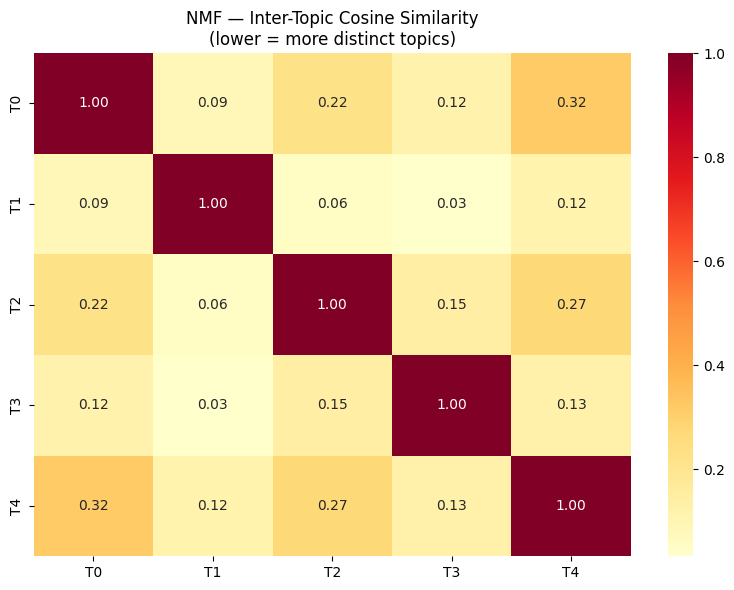

✅ Saved: nmf_similarity_heatmap.png


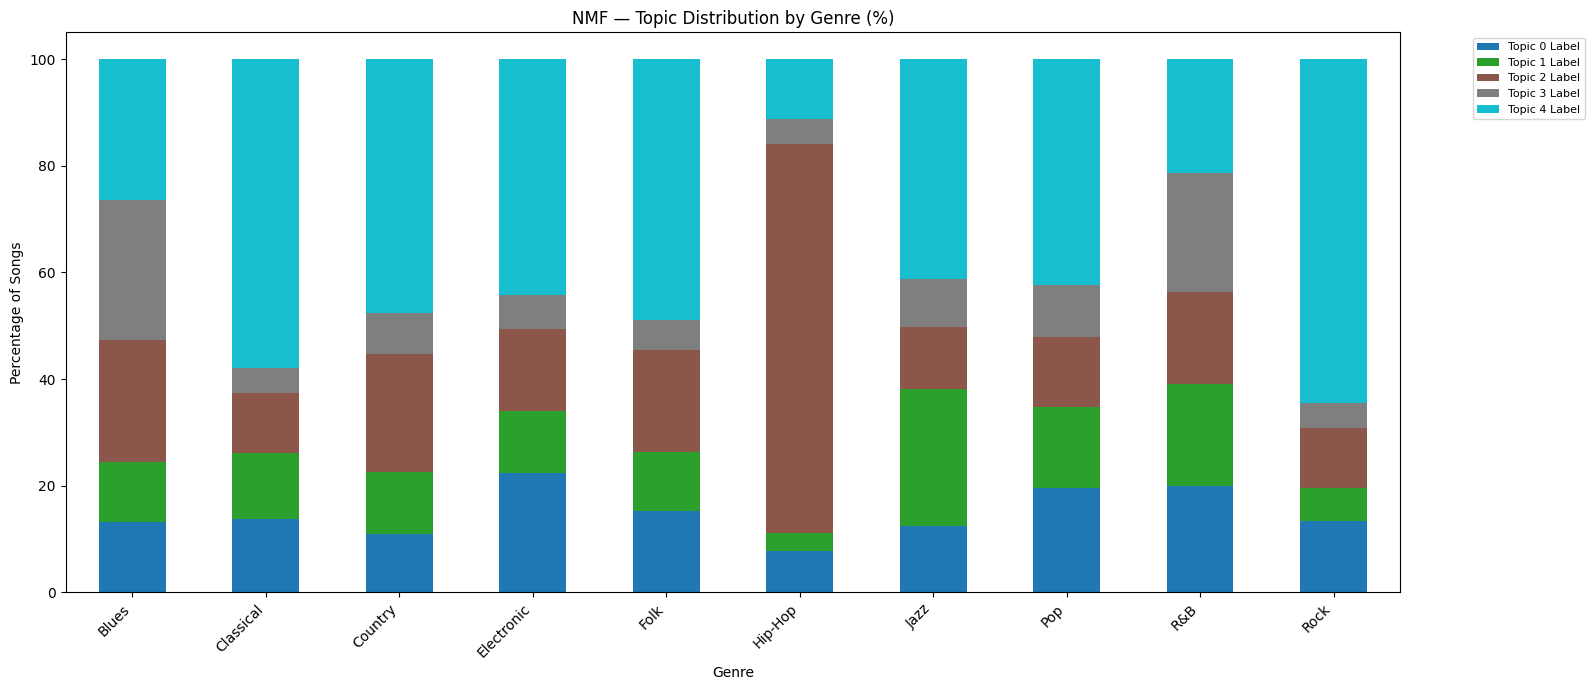

✅ Saved: nmf_genre_distribution.png


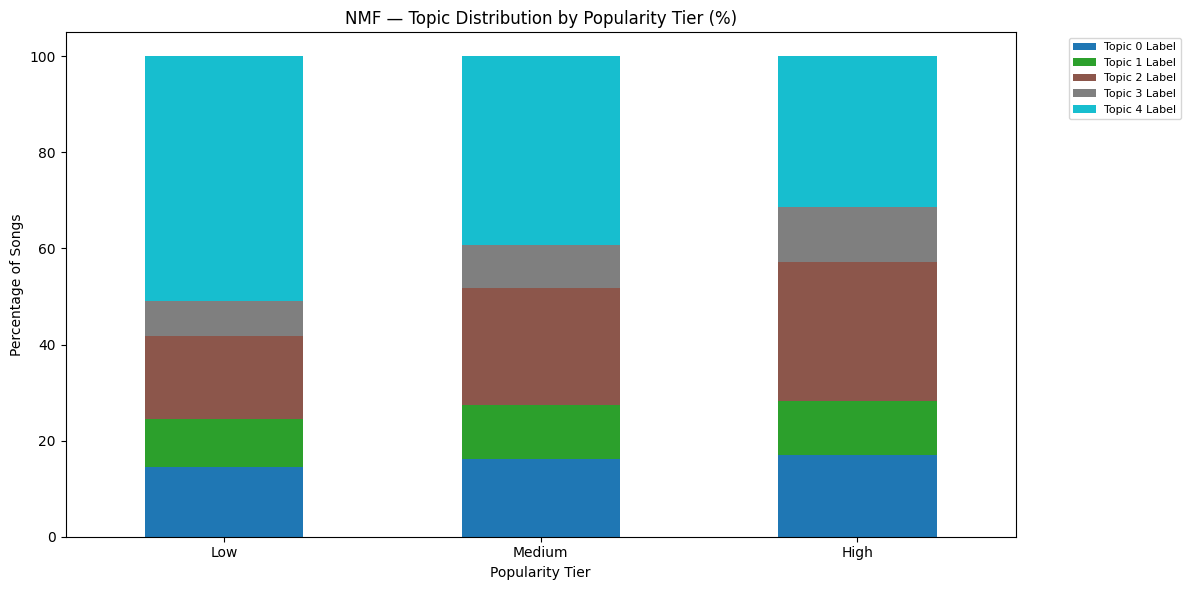

✅ Saved: nmf_popularity_distribution.png


In [ ]:
# NMF Evaluation

nmf_topic_labels = {
    0: "Topic 0 Label",   # Thinkign first what to put for this 
    1: "Topic 1 Label",
    2: "Rap / Hip Hop",
    3: "Topic 3 Label",
    4: "Topic 4 Label",
    5: "Topic 5 Label",
    6: "Topic 6 Label",
    7: "Topic 7 Label",
    8: "Topic 8 Label",
    9: "Topic 9 Label"
}

# Topic Similarity (lower is better ya)

sim_matrix = cosine_similarity(nmf_model.components_)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=[f"T{i}" for i in range(NUM_TOPICS)],
            yticklabels=[f"T{i}" for i in range(NUM_TOPICS)])
plt.title("NMF — Inter-Topic Cosine Similarity\n(lower = more distinct topics)")
plt.tight_layout()
plt.savefig("nmf_similarity_heatmap.png", bbox_inches='tight')
plt.show()
print("✅ Saved: nmf_similarity_heatmap.png")

# Topic distirbution by genre 
songs_df_nmf['popularity_tier'] = pd.cut(
    songs_df_nmf['popularity'],
    bins=[0, 33, 66, 100],
    labels=['Low', 'Medium', 'High']
)

nmf_genre = songs_df_nmf.groupby(['genre', 'nmf_topic']).size().unstack(fill_value=0)
nmf_genre.columns = [nmf_topic_labels.get(c, str(c)) for c in nmf_genre.columns]
nmf_genre_pct = nmf_genre.div(nmf_genre.sum(axis=1), axis=0) * 100

nmf_genre_pct.plot(kind='bar', stacked=True, figsize=(16, 7), colormap='tab10')
plt.title("NMF — Topic Distribution by Genre (%)")
plt.ylabel("Percentage of Songs")
plt.xlabel("Genre")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("nmf_genre_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: nmf_genre_distribution.png")

# 
nmf_pop = songs_df_nmf.groupby(['popularity_tier', 'nmf_topic']).size().unstack(fill_value=0)
nmf_pop.columns = [nmf_topic_labels.get(c, str(c)) for c in nmf_pop.columns]
nmf_pop_pct = nmf_pop.div(nmf_pop.sum(axis=1), axis=0) * 100

nmf_pop_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title("NMF — Topic Distribution by Popularity Tier (%)")
plt.ylabel("Percentage of Songs")
plt.xlabel("Popularity Tier")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("nmf_popularity_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: nmf_popularity_distribution.png")


### Demonstration and Test

In [ ]:
# Load LDA
lda_model  = LdaModel.load("./lda/lda_model_k10")
dictionary = corpora.Dictionary.load("./lda/lda_dictionary.dict")
songs_df_lda = pd.read_csv("./lda/songs_with_lda.csv")

print("Loaded LDA")

# Load NMF 
with open("./nmf/nmf_model.pkl", 'rb') as f:
    nmf_model = pickle.load(f)

with open("./nmf/tfidf_vectorizer.pkl", 'rb') as f:
    tfidf = pickle.load(f)

feature_names = tfidf.get_feature_names_out()

print(f"Loaded NMF Model") 

# Load Songs and LDA 
# Use whichever has tokens_lemma and tokens_joined
import ast

songs_df = pd.read_parquet("./data/songs_preprocessed.parquet")

def safe_parse(val):
    if isinstance(val, (list, np.ndarray)):
        return list(val)
    try:
        return ast.literal_eval(val)
    except:
        return val.strip("[]").replace("'", "").split(",")

songs_df['tokens_lemma']  = songs_df['tokens_lemma'].apply(safe_parse)
songs_df['tokens_joined'] = songs_df['tokens_lemma'].apply(lambda x: " ".join(x))

print(f"✅ Songs loaded: {len(songs_df):,} rows")

# Labels 
topic_labels = {
    0: "Life & Time",
    1: "Hip-Hop / Street",
    2: "Storytelling / Folk",
    3: "Nature & Imagery",
    4: "Caribbean / Reggae",
    5: "Romance & Party",
    6: "Dance & Movement",
    7: "Dark & Conflict",
    8: "Gospel / Spiritual",
    9: "Love & Emotion"
}

nmf_topic_labels = {
    0: "Topic 0 Label",   
    1: "Topic 1 Label",
    2: "Topic 2 Label",
    3: "Topic 3 Label",
    4: "Topic 4 Label",
}


Loaded LDA
Loaded NMF Model
✅ Songs loaded: 548,698 rows


In [12]:
# Guessing for 5 songs

sample_songs = songs_df.sample(5, random_state=42)

rows = []
for _, sample_song in sample_songs.iterrows():
    song_name   = sample_song['name']
    song_genre  = sample_song['genre']
    song_tokens = sample_song['tokens_lemma']
    song_text   = sample_song['tokens_joined']

    # LDA Prediction
    bow             = dictionary.doc2bow(song_tokens)
    lda_topics      = lda_model.get_document_topics(bow)
    lda_dominant    = max(lda_topics, key=lambda x: x[1])
    lda_topic_id    = lda_dominant[0]
    lda_topic_prob  = lda_dominant[1]
    lda_topic_label = topic_labels[lda_topic_id]
    lda_keywords    = [w for w, _ in lda_model.show_topic(lda_topic_id, topn=5)]

    # NMF Prediction
    nmf_weights     = nmf_model.transform(tfidf.transform([song_text]))[0]
    nmf_topic_id    = nmf_weights.argmax()
    nmf_topic_label = nmf_topic_labels[nmf_topic_id]
    nmf_keywords    = [feature_names[i] for i in nmf_model.components_[nmf_topic_id].argsort()[:-6:-1]]

    rows.append({
        'Song Name':      song_name,
        'Actual Genre':   song_genre,
        'LDA Topic':      lda_topic_label,
        'LDA Confidence': f"{lda_topic_prob:.2%}",
        'LDA Keywords':   lda_keywords,
        'NMF Topic':      nmf_topic_label,
        'NMF Keywords':   nmf_keywords
    })

pd.DataFrame(rows)


,Song Name,Actual Genre,LDA Topic,LDA Confidence,LDA Keywords,NMF Topic,NMF Keywords
0,Letting Go,Pop,Love & Emotion,49.85%,"[love, know, ca, like, want]",Topic 0 Label,"[know, go, let, want, wan]"
1,candayapple (feat. Paul Wall & Riff Raff),Hip-Hop,Hip-Hop / Street,50.41%,"[like, got, nigga, get, ai]",Topic 2 Label,"[got, get, like, nigga, ai]"
2,The Neglect of My Duties,Electronic,Life & Time,25.74%,"[time, never, one, day, life]",Topic 4 Label,"[time, one, life, day, away]"
3,Inappropriate,Country,Life & Time,26.63%,"[time, never, one, day, life]",Topic 4 Label,"[time, one, life, day, away]"
4,Ain't That Lovin You,Rock,Love & Emotion,51.41%,"[love, know, ca, like, want]",Topic 3 Label,"[baby, girl, come, hey, gon]"
